# Oslo Bysykkel + Seklima — Hourly Data Loading & Merging

Loads five years of Oslo Bysykkel trip data and Seklima weather data, then produces a single merged **hourly** DataFrame (one row per hour) which is used to take an initial look at the data, as well as for model training (next notebook). 

**Output:** `output/merged_hourly.csv`

## 0 · Configuration

Set these paths before running anything else.

In [1]:
from pathlib import Path

BYSYKKEL_ROOT = Path("input/turdata")

SEKLIMA_FILES = {
    "temperature":        Path("input/seklima/lufttemp.csv"),
    "precipitation":      Path("input/seklima/nedbør.csv"),
    "wind_speed":         Path("input/seklima/middelvind.csv"),
    "cloud_area_fraction": Path("input/seklima/skydekke.csv"),
}

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Config OK — output directory:", OUTPUT_DIR.resolve())

Config OK — output directory: /Users/dylan/Projects/BysykkelForecast/output


## 1 · Imports

In [2]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## 2 · Load Bysykkel trip data

Walks all yearly sub-directories under `BYSYKKEL_ROOT`, loads every monthly CSV, and concatenates them into one DataFrame. Each trip is then binned to its **start hour** (floored to the hour, timezone stripped) for joining with weather data.

In [3]:
TRIP_COLS = ["started_at", "ended_at", "duration"]

def load_bysykkel(root: Path) -> pd.DataFrame:
    csv_files = sorted(root.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(
            f"No CSV files found under '{root}'. "
            "Check that BYSYKKEL_ROOT points at the right directory."
        )

    frames = []
    for path in csv_files:
        df = pd.read_csv(path, usecols=TRIP_COLS, low_memory=False)
        frames.append(df)
        print(f"  {path.relative_to(root)}  —  {len(df):>7,} rows")

    trips = pd.concat(frames, ignore_index=True)

    # Parse datetimes
    for col in ("started_at", "ended_at"):
        trips[col] = pd.to_datetime(trips[col], errors="coerce")

    bad = trips["started_at"].isna().sum()
    if bad:
        print(f"\n  ⚠ Dropping {bad:,} rows with unparseable started_at")
    trips.dropna(subset=["started_at"], inplace=True)

    # Duration sanity filter: keep only 1 min – 24 hrs (stored in seconds)
    trips["duration"] = pd.to_numeric(trips["duration"], errors="coerce")
    before = len(trips)
    trips = trips[trips["duration"].between(60, 86_400)]
    dropped = before - len(trips)
    if dropped:
        print(f"  ⚠ Dropped {dropped:,} trips outside 1 min – 24 hr range")

    # Convert UTC → Oslo local time (CET/CEST), floor to the hour, strip tz
    trips["hour"] = (
        trips["started_at"]
        .dt.tz_convert("Europe/Oslo")
        .dt.floor("h")
        .dt.tz_localize(None)
    )
    return trips

trips = load_bysykkel(BYSYKKEL_ROOT)
print(f"\nTotal trips: {len(trips):,}  ({trips['hour'].min()} → {trips['hour'].max()})")

  2020/01.csv  —        0 rows
  2020/02.csv  —        0 rows
  2020/03.csv  —   29,563 rows
  2020/04.csv  —  121,875 rows
  2020/05.csv  —  210,882 rows
  2020/06.csv  —  297,959 rows
  2020/07.csv  —  200,715 rows
  2020/08.csv  —  292,848 rows
  2020/09.csv  —  251,072 rows
  2020/10.csv  —  162,519 rows
  2020/11.csv  —   90,272 rows
  2020/12.csv  —   38,349 rows
  2021/01.csv  —   36,039 rows
  2021/02.csv  —   35,342 rows
  2021/03.csv  —   64,714 rows
  2021/04.csv  —  122,509 rows
  2021/05.csv  —  144,625 rows
  2021/06.csv  —  217,255 rows
  2021/07.csv  —  162,584 rows
  2021/08.csv  —  194,151 rows
  2021/09.csv  —  190,005 rows
  2021/10.csv  —  138,164 rows
  2021/11.csv  —   98,666 rows
  2021/12.csv  —   15,230 rows
  2022/01.csv  —   15,378 rows
  2022/02.csv  —   17,533 rows
  2022/03.csv  —   40,471 rows
  2022/04.csv  —  116,909 rows
  2022/05.csv  —  164,516 rows
  2022/06.csv  —  195,454 rows
  2022/07.csv  —  159,261 rows
  2022/08.csv  —  207,333 rows
  2022/0

### 2a · Preview raw trip data

In [4]:
trips.head(3)

,started_at,ended_at,duration,hour
0,2020-03-17 23:11:09.156000+00:00,2020-03-17 23:16:37.235000+00:00,328,2020-03-18
1,2020-03-17 23:33:08.959000+00:00,2020-03-17 23:39:15.662000+00:00,366,2020-03-18
2,2020-03-17 23:51:55.463000+00:00,2020-03-17 23:56:39.069000+00:00,283,2020-03-18


### 2b · Aggregate to hourly counts

In [5]:
def aggregate_hourly_trips(trips: pd.DataFrame) -> pd.DataFrame:
    """One row per hour: trip count + duration stats."""
    return (
        trips.groupby("hour")
        .agg(
            trip_count          = ("started_at", "count"),
            avg_duration_min    = ("duration", lambda s: round(s.mean() / 60, 1)),
            median_duration_min = ("duration", lambda s: round(s.median() / 60, 1)),
        )
        .reset_index()
    )

hourly_trips = aggregate_hourly_trips(trips)
print(f"Hourly trip rows: {len(hourly_trips):,}")
hourly_trips.head()

Hourly trip rows: 43,571


,hour,trip_count,avg_duration_min,median_duration_min
0,2020-03-18 00:00:00,3,5.4,5.5
1,2020-03-18 06:00:00,21,11.7,9.8
2,2020-03-18 07:00:00,56,10.5,9.6
3,2020-03-18 08:00:00,63,11.8,9.1
4,2020-03-18 09:00:00,45,10.0,8.5


## 3 · Load Seklima weather data

Loads each variable file at its native hourly resolution. Seklima quirks handled automatically:
- Metadata preamble before the actual header
- Auto-detected separator (`;` or tab)
- Norwegian decimal commas (`3,7` → `3.7`)
- Missing-value markers (`-`, empty strings)

In [6]:
SEKLIMA_VAR_NAMES = {
    "temperature":        "temp_c",
    "precipitation":      "precip_mm",
    "wind_speed":         "wind_speed_ms",
    "cloud_area_fraction": "cloud_area_fraction",
}

In [7]:
def _find_header_row(path: Path) -> int:
    """Return the 0-based index of the first line containing 'Stasjon' or 'Tid'."""
    with open(path, encoding="utf-8-sig") as fh:
        for i, line in enumerate(fh):
            if "Stasjon" in line or "Tid" in line:
                return i
    raise ValueError(f"Could not find a header row in '{path}'.")


def _detect_separator(path: Path, header_row: int) -> str:
    """Count ';' vs tab on the header line to pick the right separator."""
    with open(path, encoding="utf-8-sig") as fh:
        for i, line in enumerate(fh):
            if i == header_row:
                return ";" if line.count(";") >= line.count("\t") else "\t"
    return ";"


def load_seklima_file(path: Path, var_key: str) -> pd.DataFrame:
    """
    Load one Seklima variable file.
    Returns a two-column DataFrame: hour (tz-naive, floored to hour) | <var_name>
    """
    var_name   = SEKLIMA_VAR_NAMES[var_key]
    header_row = _find_header_row(path)
    sep        = _detect_separator(path, header_row)

    df = pd.read_csv(
        path,
        skiprows=header_row,
        sep=sep,
        decimal=",",
        encoding="utf-8-sig",
        na_values=["-", " ", ""],
        low_memory=False,
    )

    # Timestamp column
    time_col = next((c for c in df.columns if "Tid" in c or "tid" in c), None)
    if time_col is None:
        raise ValueError(f"No time column found in '{path}'. Columns: {list(df.columns)}")
    df["hour"] = (
        pd.to_datetime(df[time_col], dayfirst=True, errors="coerce")
        .dt.floor("h")                 # floor while still naive (avoids DST ambiguity)
        .dt.tz_localize("Etc/GMT-1")   # Seklima uses NNT = fixed UTC+1
        .dt.tz_convert("Europe/Oslo")  # convert to CET/CEST with DST
        .dt.tz_localize(None)
    )
    df.dropna(subset=["hour"], inplace=True)

    # Value column: first numeric non-metadata column, with comma-coercion fallback
    skip = {time_col, "Navn", "Stasjon"}
    value_col = next(
        (c for c in df.columns if c not in skip and pd.api.types.is_numeric_dtype(df[c])),
        None,
    )
    if value_col is None:
        for c in df.columns:
            if c in skip:
                continue
            coerced = (
                df[c].astype(str)
                .str.replace(",", ".", regex=False)
                .pipe(pd.to_numeric, errors="coerce")
            )
            if coerced.notna().sum() > 0:
                df[c] = coerced
                value_col = c
                break

    if value_col is None:
        raise ValueError(
            f"Could not identify a numeric value column in '{path}'.\n"
            f"Columns found: {list(df.columns)}  Separator: {repr(sep)}"
        )

    df[var_name] = df[value_col]
    valid = df[var_name].notna().sum()
    print(f"  {var_key:<16} — {len(df):,} rows  ({valid:,} non-null)  [sep={repr(sep)}]")
    return df[["hour", var_name]].copy()

In [8]:
def load_hourly_weather(seklima_files: dict) -> pd.DataFrame:
    """Load all variable files and outer-join on the hourly timestamp."""
    parts = []
    for var_key, path in seklima_files.items():
        if path is None:
            print(f"  Skipping {var_key} (path is None)")
            continue
        if not path.exists():
            print(f"  ⚠ '{path}' not found — skipping {var_key}")
            continue
        parts.append(load_seklima_file(path, var_key).set_index("hour"))

    if not parts:
        raise FileNotFoundError("No Seklima files could be loaded.")

    weather = parts[0]
    for part in parts[1:]:
        weather = weather.join(part, how="outer")

    weather = weather.sort_index()
    weather.index.name = "hour"
    return weather.reset_index()

hourly_weather = load_hourly_weather(SEKLIMA_FILES)
print(f"\nHourly weather rows: {len(hourly_weather):,}  "
      f"({hourly_weather['hour'].min()} → {hourly_weather['hour'].max()})")

  temperature      — 55,031 rows  (55,031 non-null)  [sep=';']
  precipitation    — 54,860 rows  (54,860 non-null)  [sep=';']
  wind_speed       — 55,031 rows  (55,031 non-null)  [sep=';']
  cloud_area_fraction — 55,031 rows  (55,031 non-null)  [sep=';']

Hourly weather rows: 55,115  (2020-01-01 00:00:00 → 2026-04-11 23:00:00)


### 3a · Preview hourly weather

In [9]:
hourly_weather.head()

,hour,temp_c,precip_mm,wind_speed_ms,cloud_area_fraction
0,2020-01-01 00:00:00,2.4,0.0,2.9,100.0
1,2020-01-01 01:00:00,2.7,0.0,2.5,100.0
2,2020-01-01 02:00:00,1.3,0.0,0.7,100.0
3,2020-01-01 03:00:00,2.9,0.0,4.2,100.0
4,2020-01-01 04:00:00,2.8,0.0,2.2,100.0


## 4 · Merge trips and weather

Inner join on `hour`. Hours with no trip data or no weather reading are excluded. Note that hours outside the operating window (01:00–04:59) simply won't appear in `hourly_trips` — they'll show up in the coverage report as 'weather hours with no trips'.

In [10]:
def merge_hourly(hourly_trips: pd.DataFrame, hourly_weather: pd.DataFrame) -> pd.DataFrame:
    df = pd.merge(hourly_trips, hourly_weather, on="hour", how="inner")
    df = df.sort_values("hour").reset_index(drop=True)

    trip_hours    = set(hourly_trips["hour"])
    weather_hours = set(hourly_weather["hour"])
    print(f"Merged rows             : {len(df):,} hours")
    print(f"Trip hours, no weather  : {len(trip_hours - weather_hours):,}")
    print(f"Weather hours, no trips : {len(weather_hours - trip_hours):,}")
    print(f"Date range              : {df['hour'].min()} → {df['hour'].max()}")
    return df

df = merge_hourly(hourly_trips, hourly_weather)

Merged rows             : 43,571 hours
Trip hours, no weather  : 0
Weather hours, no trips : 11,454
Date range              : 2020-03-18 00:00:00 → 2026-03-03 19:00:00


### 4a · Add calendar features

Hour-of-day and day-of-week capture the strong temporal rhythms in bike use and will be important features for the forecasting model.

In [11]:
df["date"]        = df["hour"].dt.normalize()
df["hour_of_day"] = df["hour"].dt.hour
df["day_of_week"] = df["hour"].dt.dayofweek   # 0=Mon … 6=Sun
df["is_weekend"]  = df["day_of_week"].isin([5, 6]).astype(int)
df["month"]       = df["hour"].dt.month

df.head()

,hour,trip_count,avg_duration_min,median_duration_min,temp_c,precip_mm,wind_speed_ms,cloud_area_fraction,date,hour_of_day,day_of_week,is_weekend,month
0,2020-03-18 00:00:00,3,5.4,5.5,5.1,0.0,2.3,100.0,2020-03-18,0,2,0,3
1,2020-03-18 06:00:00,21,11.7,9.8,5.0,0.0,3.6,81.2,2020-03-18,6,2,0,3
2,2020-03-18 07:00:00,56,10.5,9.6,4.7,0.0,3.7,97.9,2020-03-18,7,2,0,3
3,2020-03-18 08:00:00,63,11.8,9.1,4.7,0.0,3.5,100.0,2020-03-18,8,2,0,3
4,2020-03-18 09:00:00,45,10.0,8.5,4.9,0.0,3.1,85.4,2020-03-18,9,2,0,3


In [12]:
# Drop Bysykkel service-closed hours (01:00–04:59 Oslo local time)
before = len(df)
df = df[~df["hour_of_day"].isin([1, 2, 3, 4])].reset_index(drop=True)
print(f"Dropped {before - len(df):,} closed-hours rows  ({len(df):,} remaining)")

Dropped 239 closed-hours rows  (43,332 remaining)


### 4b · Missing value summary

In [13]:
missing = df.isna().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values — clean merge.")
else:
    print(f"{'Column':<25} {'Missing':>8}  {'%':>6}")
    print("-" * 44)
    for col, n in missing.items():
        print(f"{col:<25} {n:>8,}  {100 * n / len(df):>5.1f}%")

Column                     Missing       %
--------------------------------------------
precip_mm                      141    0.3%


### 4c · Dataset overview

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43332 entries, 0 to 43331
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   hour                 43332 non-null  datetime64[us]
 1   trip_count           43332 non-null  int64         
 2   avg_duration_min     43332 non-null  float64       
 3   median_duration_min  43332 non-null  float64       
 4   temp_c               43332 non-null  float64       
 5   precip_mm            43191 non-null  float64       
 6   wind_speed_ms        43332 non-null  float64       
 7   cloud_area_fraction  43332 non-null  float64       
 8   date                 43332 non-null  datetime64[us]
 9   hour_of_day          43332 non-null  int32         
 10  day_of_week          43332 non-null  int32         
 11  is_weekend           43332 non-null  int64         
 12  month                43332 non-null  int32         
dtypes: datetime64[us](2), float64(6), int32(3)

In [15]:
df.describe().round(2)

,hour,trip_count,avg_duration_min,median_duration_min,temp_c,precip_mm,wind_speed_ms,cloud_area_fraction,date,hour_of_day,day_of_week,is_weekend,month
count,43332,43332.00,43332.00,43332.00,43332.00,43191.00,43332.00,43332.00,43332,43332.00,43332.0,43332.00,43332.00
mean,2023-03-10 10:46:10.451398,179.82,11.82,8.85,8.10,0.10,2.69,69.05,2023-03-09 21:26:42.104680,13.32,3.0,0.28,6.56
min,2020-03-18 00:00:00,1.00,1.60,1.30,-22.50,0.00,0.00,0.00,2020-03-18 00:00:00,0.00,0.0,0.00,1.00
25%,2021-09-11 10:45:00,32.00,9.60,7.70,1.50,0.00,1.50,33.30,2021-09-11 00:00:00,9.00,1.0,0.00,4.00
50%,2023-03-09 15:30:00,115.00,11.20,8.70,8.30,0.00,2.40,91.70,2023-03-09 00:00:00,14.00,3.0,0.00,7.00
75%,2024-09-05 18:15:00,266.00,13.50,9.80,15.00,0.00,3.60,100.00,2024-09-05 00:00:00,19.00,5.0,1.00,10.00
max,2026-03-03 19:00:00,2555.00,115.80,90.60,32.60,32.50,12.10,100.00,2026-03-03 00:00:00,23.00,6.0,1.00,12.00
std,NaN,192.71,3.52,2.08,8.67,0.54,1.62,38.03,NaN,6.14,2.0,0.45,3.44


## 5 · Save

In [16]:
out_path = OUTPUT_DIR / "merged_hourly.csv"
df.to_csv(out_path, index=False)
print(f"Saved → {out_path.resolve()}")
print(f"Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nColumns:")
for col in df.columns:
    print(f"  {col}")

Saved → /Users/dylan/Projects/BysykkelForecast/output/merged_hourly.csv
Shape  : 43,332 rows × 13 columns

Columns:
  hour
  trip_count
  avg_duration_min
  median_duration_min
  temp_c
  precip_mm
  wind_speed_ms
  cloud_area_fraction
  date
  hour_of_day
  day_of_week
  is_weekend
  month


## 6 · Initial look

Pearson r between each variable and `trip_count`, a full correlation heatmap, and a scatter grid. Note that `hour_of_day`, `day_of_week`, and `month` are treated as numeric here — the r values capture monotonic tendencies but not the non-linear U-shapes you'd see in a box plot. Those are better explored visually in the scatter plots and box plots.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### 6a · Pearson r table

In [18]:
CORR_VARS = [
    "temp_c", "precip_mm", "wind_speed_ms", "cloud_area_fraction",
    "hour_of_day", "day_of_week", "month",
]

corr_vars = [v for v in CORR_VARS if v in df.columns]
corr_data = df[["trip_count"] + corr_vars].copy()
for col in corr_data.columns:
    corr_data[col] = pd.to_numeric(corr_data[col], errors="coerce")

In [19]:
print(f"{'Feature':<25} {'Pearson r':>10}  {'p-value':>10}  sig")
print("─" * 52)
for col in corr_vars:
    sub = corr_data[["trip_count", col]].dropna()
    r, p = stats.pearsonr(sub[col], sub["trip_count"])
    stars = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"{col:<25} {r:>+10.3f}  {p:>10.4f}  {stars}")

Feature                    Pearson r     p-value  sig
────────────────────────────────────────────────────
temp_c                        +0.627      0.0000  ***
precip_mm                     -0.078      0.0000  ***
wind_speed_ms                 +0.099      0.0000  ***
cloud_area_fraction           -0.124      0.0000  ***
hour_of_day                   +0.139      0.0000  ***
day_of_week                   -0.128      0.0000  ***
month                         +0.153      0.0000  ***


### 6b · Correlation heatmap

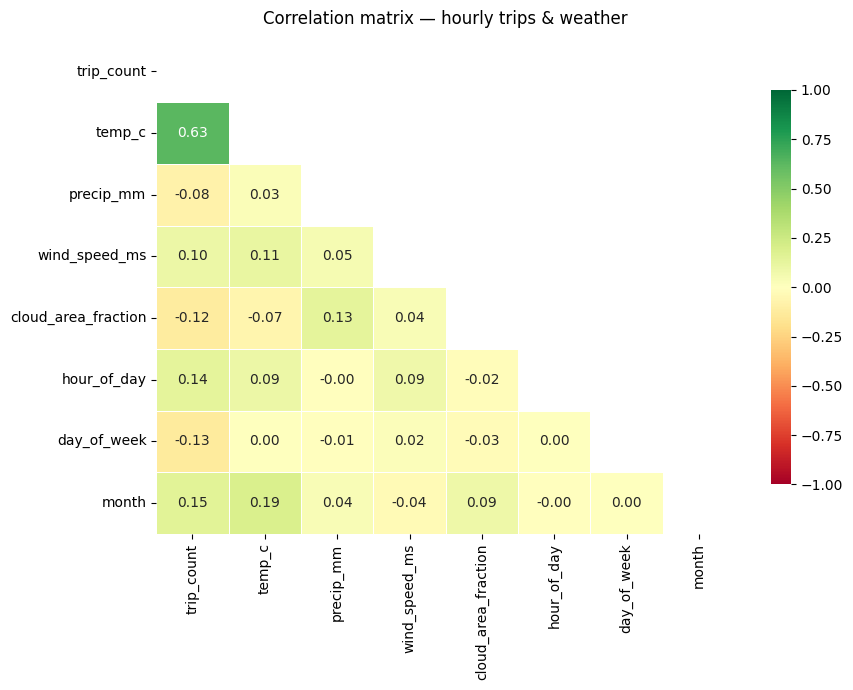

In [20]:
fig, ax = plt.subplots(figsize=(9, 7))

matrix = corr_data.corr()
mask   = np.triu(np.ones_like(matrix, dtype=bool))

sns.heatmap(
    matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Correlation matrix — hourly trips & weather", pad=12)
plt.tight_layout()
plt.show()

### 6c · Scatter / bar grid

`temp_c` is shown as a scatter with a linear trend. The calendar variables (`hour_of_day`, `day_of_week`, `month`) are shown as bar plots of **mean trips per group**, which better captures their non-linear structure — e.g. the commuter double-peak across hours of day.

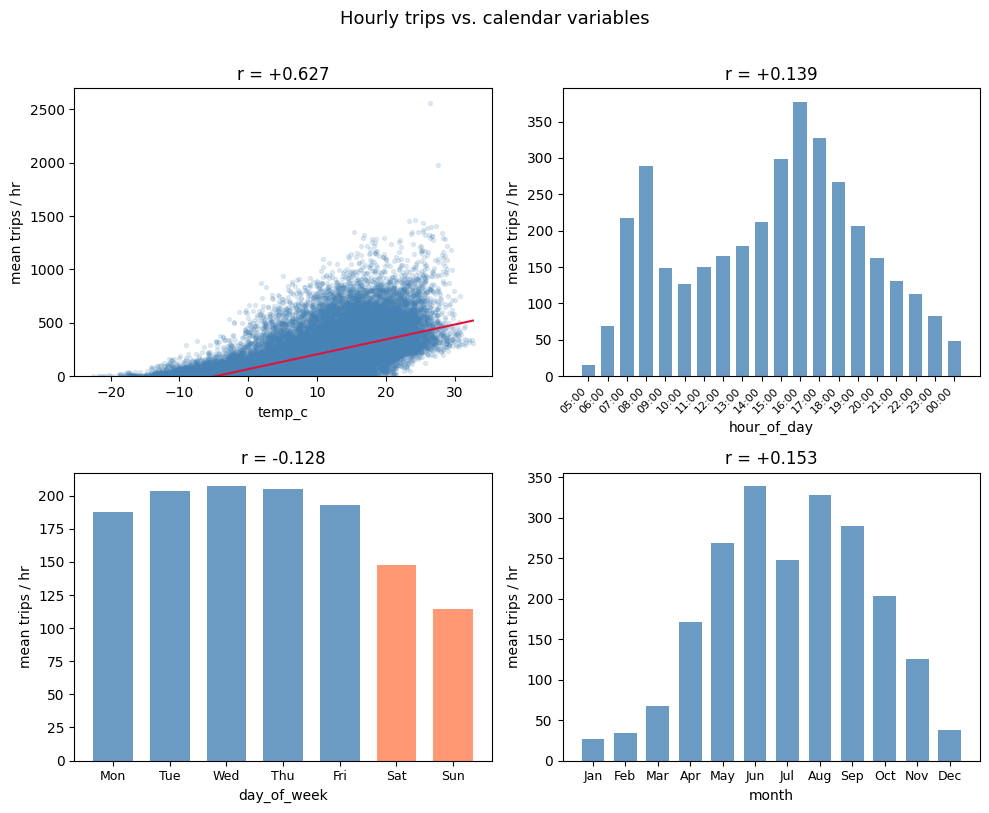

In [21]:
from scipy import stats

plot_vars = ["temp_c", "hour_of_day", "day_of_week", "month"]

# Service hours in display order: 05:00 → 23:00, then 00:00 (closes at 01:00)
service_hours     = list(range(5, 24)) + [0]
hour_tick_labels  = [f"{h:02d}:00" for h in range(5, 24)] + ["00:00"]

ncols = 2
nrows = -(-len(plot_vars) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

# ── First panel: temp_c — scatter with linear trend ────────────────────────
var = plot_vars[0]   # 'temp_c'
ax  = axes[0]
sub = corr_data[[var, 'trip_count']].dropna()
r, _ = stats.pearsonr(sub[var], sub['trip_count'])

ax.scatter(sub[var], sub['trip_count'], alpha=0.15, s=8, color='steelblue')
m, b = np.polyfit(sub[var], sub['trip_count'], 1)
x    = np.linspace(sub[var].min(), sub[var].max(), 100)
ax.plot(x, m * x + b, color='crimson', lw=1.5)
ax.set_xlabel(var)
ax.set_ylabel('mean trips / hr')
ax.set_ylim(bottom=0)
ax.set_title(f'r = {r:+.3f}')

# ── Remaining panels: bar plots of mean trips per group ────────────────────
dow_labels   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for idx, var in enumerate(plot_vars[1:]):
    ax  = axes[idx + 1]
    sub = corr_data[[var, 'trip_count']].dropna()

    # For day_of_week: restrict to service hours only
    if var == 'day_of_week':
        sub = sub[corr_data['hour_of_day'].isin(service_hours)]

    r, _ = stats.pearsonr(sub[var], sub['trip_count'])

    if var == 'hour_of_day':
        # Display in service-hour order
        grouped  = sub.groupby(var)['trip_count'].mean()
        y_vals   = [grouped.get(h, 0) for h in service_hours]
        x_labels = hour_tick_labels
        colors   = ['steelblue'] * len(y_vals)
        rotation, fontsize = 45, 8
    elif var == 'day_of_week':
        grouped  = sub.groupby(var)['trip_count'].mean()
        y_vals   = grouped.values
        x_labels = [dow_labels[int(k)] for k in grouped.index]
        colors   = ['steelblue' if int(k) < 5 else 'coral' for k in grouped.index]
        rotation, fontsize = 0, 9
    elif var == 'month':
        grouped  = sub.groupby(var)['trip_count'].mean()
        y_vals   = grouped.values
        x_labels = [month_labels[int(k) - 1] for k in grouped.index]
        colors   = ['steelblue'] * len(y_vals)
        rotation, fontsize = 0, 9
    else:
        grouped  = sub.groupby(var)['trip_count'].mean()
        y_vals   = grouped.values
        x_labels = [str(k) for k in grouped.index]
        colors   = ['steelblue'] * len(y_vals)
        rotation, fontsize = 0, 9

    ax.bar(range(len(y_vals)), y_vals, color=colors, alpha=0.8, width=0.7)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=rotation, ha='right' if rotation else 'center', fontsize=fontsize)
    ax.set_xlabel(var)
    ax.set_ylabel('mean trips / hr')
    ax.set_ylim(bottom=0)
    ax.set_title(f'r = {r:+.3f}')

for j in range(len(plot_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Hourly trips vs. calendar variables', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 6d · Mean trips by hour of day — weekdays vs. weekends

Bar plots of mean hourly trip counts by hour of day, split by day type. Weekdays show a clear commuter double-peak (morning and evening rush); weekends show a single broader leisure peak in the early afternoon. Hours run from service opening (05:00) to service closure (01:00 next day).

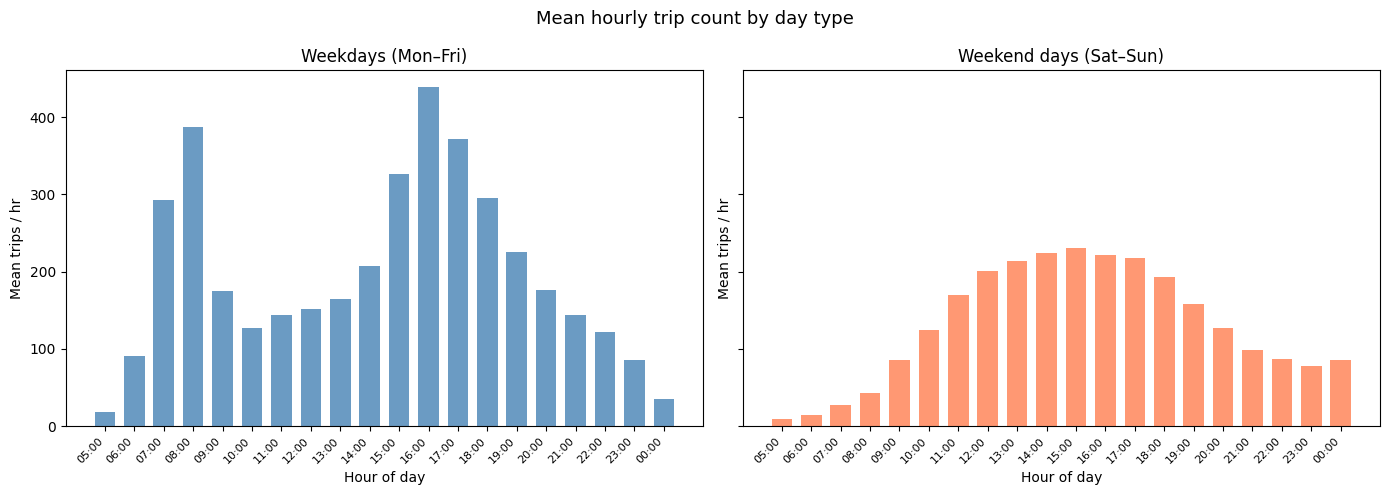

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

weekday_df = df[df["day_of_week"] < 5]
weekend_df = df[df["day_of_week"] >= 5]

for ax, subset, title, color in [
    (axes[0], weekday_df, "Weekdays (Mon–Fri)",     "steelblue"),
    (axes[1], weekend_df, "Weekend days (Sat–Sun)", "coral"),
]:
    means = [subset.loc[subset["hour_of_day"] == h, "trip_count"].mean()
             for h in service_hours]
    ax.bar(range(len(service_hours)), means, color=color, alpha=0.8, width=0.7)
    ax.set_xticks(range(len(service_hours)))
    ax.set_xticklabels(hour_tick_labels, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Mean trips / hr")
    ax.set_title(title)
    ax.set_ylim(bottom=0)

plt.suptitle("Mean hourly trip count by day type", fontsize=13)
plt.tight_layout()
plt.show()